In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from sklearn import preprocessing
from xgboost import XGBClassifier 
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, accuracy_score, precision_score, recall_score, f1_score

In [38]:
data = pd.read_csv('../../../data/labeled_dataset.csv')


In [39]:
data['Date'] = pd.to_datetime(data['Date'])

In [40]:
data.describe()

,Date,GSPC,VIX,SPY Volume,GDP,Core_Inflation,Unemployment,M2,Return,Return_5d,...,quarter,GDP_YoY,month,Core_Inflation_YoY,M2_YoY,Peak,Drawdown,VIX_Change,VIX_Change_5d,segment
count,8066,8066.000000,8066.000000,8.066000e+03,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,...,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000
mean,2010-02-01 02:29:04.210265344,2019.295843,19.723230,8.589037e+07,17170.979583,90.894071,5.538718,10353.092165,0.000400,0.001953,...,2.511654,0.025600,6.535953,0.020431,0.060607,2228.514370,-0.110974,0.001169,0.004689,51.914208
min,1994-01-27 00:00:00,438.920013,9.140000,5.200000e+03,10939.116000,66.902000,3.400000,3474.900000,-0.119841,-0.183401,...,1.000000,-0.084695,1.000000,0.006256,-0.046910,477.049988,-0.567754,-18.710003,-26.379997,0.000000
25%,2002-01-30 06:00:00,1102.489990,14.010000,1.955088e+07,14372.785000,76.871000,4.300000,5460.900000,-0.004530,-0.009653,...,2.000000,0.018667,4.000000,0.015199,0.042003,1527.459961,-0.184359,-0.690001,-1.400000,28.000000
50%,2010-02-02 12:00:00,1374.145020,17.900000,6.509505e+07,16872.266000,89.446000,5.000000,8523.500000,0.000673,0.003542,...,3.000000,0.026013,7.000000,0.018279,0.057890,1565.150024,-0.057564,-0.075001,-0.120001,53.000000
75%,2018-02-05 18:00:00,2626.942505,23.110001,1.136950e+08,19882.352000,101.198000,6.100000,13919.000000,0.005842,0.014946,...,4.000000,0.034949,10.000000,0.021915,0.071864,2872.870117,-0.011118,0.580000,1.190000,76.000000
max,2026-02-13 00:00:00,6978.600098,82.690002,8.710263e+08,24026.834000,127.422000,14.800000,22411.000000,0.115800,0.191112,...,4.000000,0.123857,12.000000,0.057016,0.281678,6978.600098,0.000000,24.860001,35.850002,105.000000
std,NaN,1460.854641,8.015070,8.985808e+07,3513.615972,16.055677,1.783561,5940.148670,0.011737,0.023961,...,1.115822,0.020355,3.430906,0.009300,0.043241,1472.117991,0.123453,1.720643,3.254432,30.565074


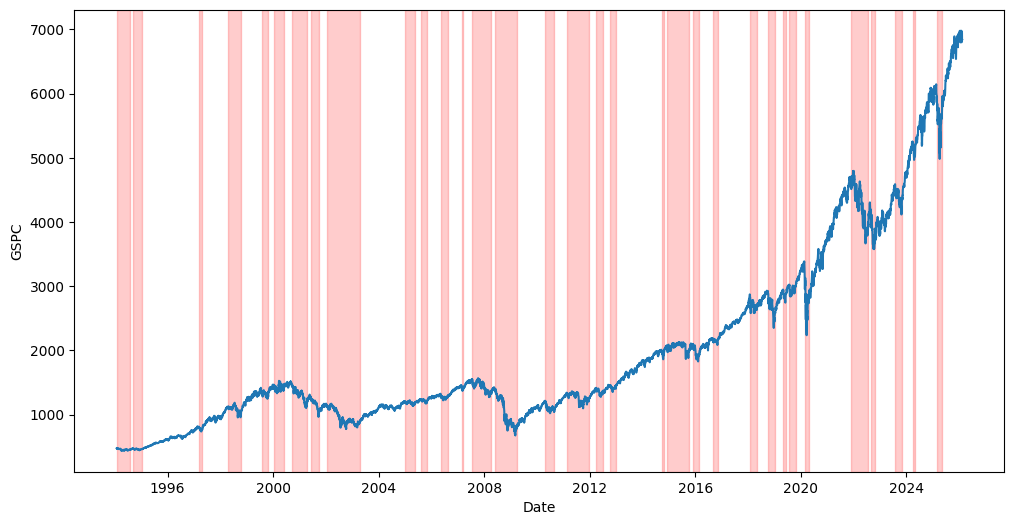

In [41]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='GSPC', data=data)
plt.fill_between(
    data['Date'], 
    0, 1, 
    where=(data['regime'] == 'bear'),             
    color='red',                              
    alpha=0.2,                                
    transform=plt.gca().get_xaxis_transform(), 
    label='Bear Regime'
)

In [42]:
data['regime_binary']= np.where(data['regime']=='bull',1,0)


In [43]:
data

,Date,GSPC,VIX,SPY Volume,GDP,Core_Inflation,Unemployment,M2,Return,Return_5d,...,month,Core_Inflation_YoY,M2_YoY,Peak,Drawdown,VIX_Change,VIX_Change_5d,regime,segment,regime_binary
0,1994-01-27,477.049988,10.300000,344500,10939.116,66.902,6.6,3474.9,0.008136,0.004358,...,1,0.022466,0.016320,477.049988,0.000000,-0.870000,-0.860000,bear,0,0
1,1994-01-28,478.700012,9.940000,356500,10939.116,66.902,6.6,3474.9,0.003459,0.008384,...,1,0.020516,0.017689,478.700012,0.000000,-0.360001,-1.150001,bear,0,0
2,1994-01-31,481.609985,10.630000,313800,10939.116,66.902,6.6,3474.9,0.006079,0.020425,...,1,0.020516,0.017689,481.609985,0.000000,0.690001,-0.970000,bear,0,0
3,1994-02-01,479.619995,10.650000,303600,10939.116,67.047,6.6,3475.7,-0.004132,0.018474,...,2,0.022728,0.017924,481.609985,-0.004132,0.020000,-0.730000,bear,0,0
4,1994-02-02,482.000000,10.610000,307600,10939.116,67.047,6.6,3475.7,0.004962,0.018597,...,2,0.022728,0.017924,482.000000,0.000000,-0.040000,-0.560000,bear,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8061,2026-02-09,6964.819824,17.360001,73885200,24026.834,127.422,4.4,22411.0,0.004691,-0.001666,...,2,0.018195,0.039240,6978.600098,-0.001975,-3.010000,1.020000,bull,105,1
8062,2026-02-10,6941.810059,17.790001,65185700,24026.834,127.422,4.4,22411.0,-0.003304,0.003469,...,2,0.018195,0.039240,6978.600098,-0.005272,0.430000,-0.209999,bull,105,1
8063,2026-02-11,6941.470215,17.650000,76353900,24026.834,127.422,4.4,22411.0,-0.000049,0.008536,...,2,0.018195,0.039240,6978.600098,-0.005321,-0.140001,-0.990000,bull,105,1
8064,2026-02-12,6832.759766,20.820000,118829000,24026.834,127.422,4.4,22411.0,-0.015661,0.005054,...,2,0.018195,0.039240,6978.600098,-0.020898,3.170000,-0.950001,bull,105,1


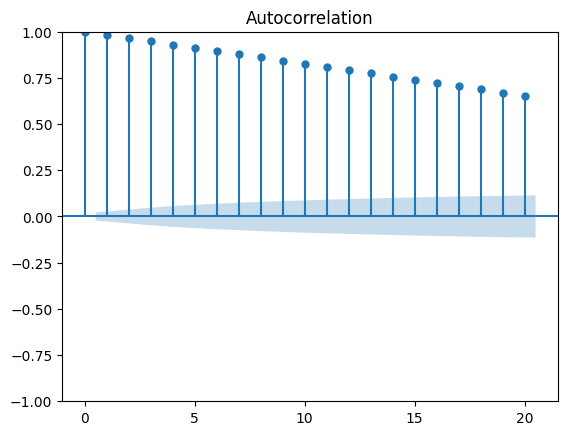

In [44]:

plot_acf(data['regime_binary'], lags=20)
plt.show()

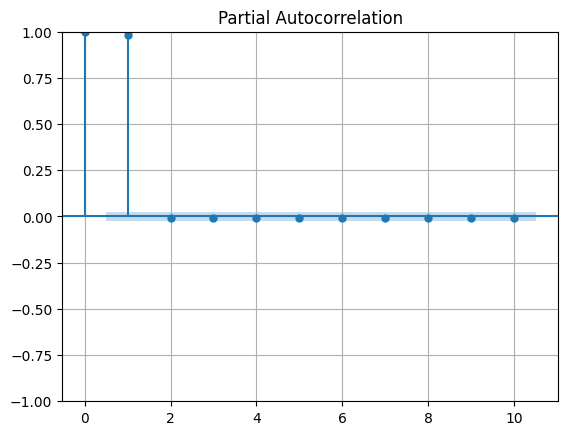

In [45]:

plot_pacf(data['regime_binary'], lags=10)
plt.grid()
plt.show()
### AR(1) model

In [46]:
data['Risk_Adj_Return_20d'] = data['Return_20d'] / (data['VIX'] + 0.00001)

data['SPY_Volume_20d_MA'] = data['SPY Volume'].rolling(window=20).mean()

data['Relative_Volume'] = data['SPY Volume'] / data['SPY_Volume_20d_MA']

data['MACD_Hist_Accel'] = data['MACD_Hist'] - data['MACD_Hist'].shift(1)

data = data.drop(columns=['SPY_Volume_20d_MA']).dropna()

In [47]:
data['lagged_target_1'] = data['regime_binary'].shift(-1)
# data['lagged_target_10'] = data['regime_binary'].shift(-10)
# data['lagged_target_30'] = data['regime_binary'].shift(-30)

In [48]:
data_1 = data.dropna(subset=['lagged_target_1'])



In [49]:
stationary_features = [
    'Return', 'Return_5d', 'Return_20d', 'Return_Smooth', 
    'RSI_14', 'MACD_Hist', 'Drawdown', 
    'VIX', 'VIX_Change', 'VIX_Change_5d', 
    'GDP_YoY', 'Core_Inflation_YoY', 'M2_YoY', 'Unemployment',
    'Risk_Adj_Return_20d','Relative_Volume',
    'MACD_Hist_Accel'
]

In [50]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

def station_test(df):
    for col in df.columns:
        res = adfuller(df[col].dropna())
        print('p_value =', np.round(res[1], 5), 'for', col)

station_test(data[stationary_features])


p_value = 0.0 for Return
p_value = 0.0 for Return_5d
p_value = 0.0 for Return_20d
p_value = 0.0 for Return_Smooth
p_value = 0.0 for RSI_14
p_value = 0.0 for MACD_Hist
p_value = 0.12044 for Drawdown
p_value = 0.0 for VIX
p_value = 0.0 for VIX_Change
p_value = 0.0 for VIX_Change_5d
p_value = 8e-05 for GDP_YoY
p_value = 0.29915 for Core_Inflation_YoY
p_value = 0.00489 for M2_YoY
p_value = 0.01537 for Unemployment
p_value = 0.0 for Risk_Adj_Return_20d
p_value = 0.0 for Relative_Volume
p_value = 0.0 for MACD_Hist_Accel


<Axes: xlabel='Date', ylabel='Core_Inflation_YoY'>

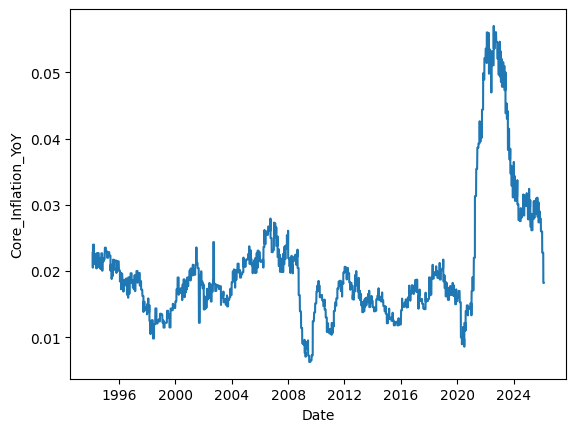

In [51]:
sns.lineplot(x='Date', y='Core_Inflation_YoY', data=data)


<Axes: xlabel='Date', ylabel='Drawdown'>

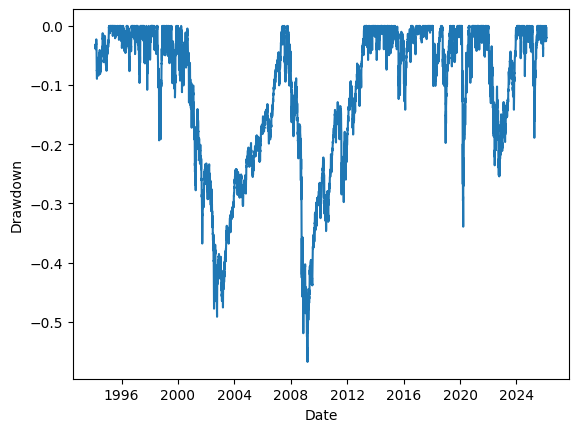

In [52]:
sns.lineplot(x='Date', y='Drawdown', data=data)

In [53]:

X = data_1[stationary_features]
y = data_1['lagged_target_1']



<Axes: >

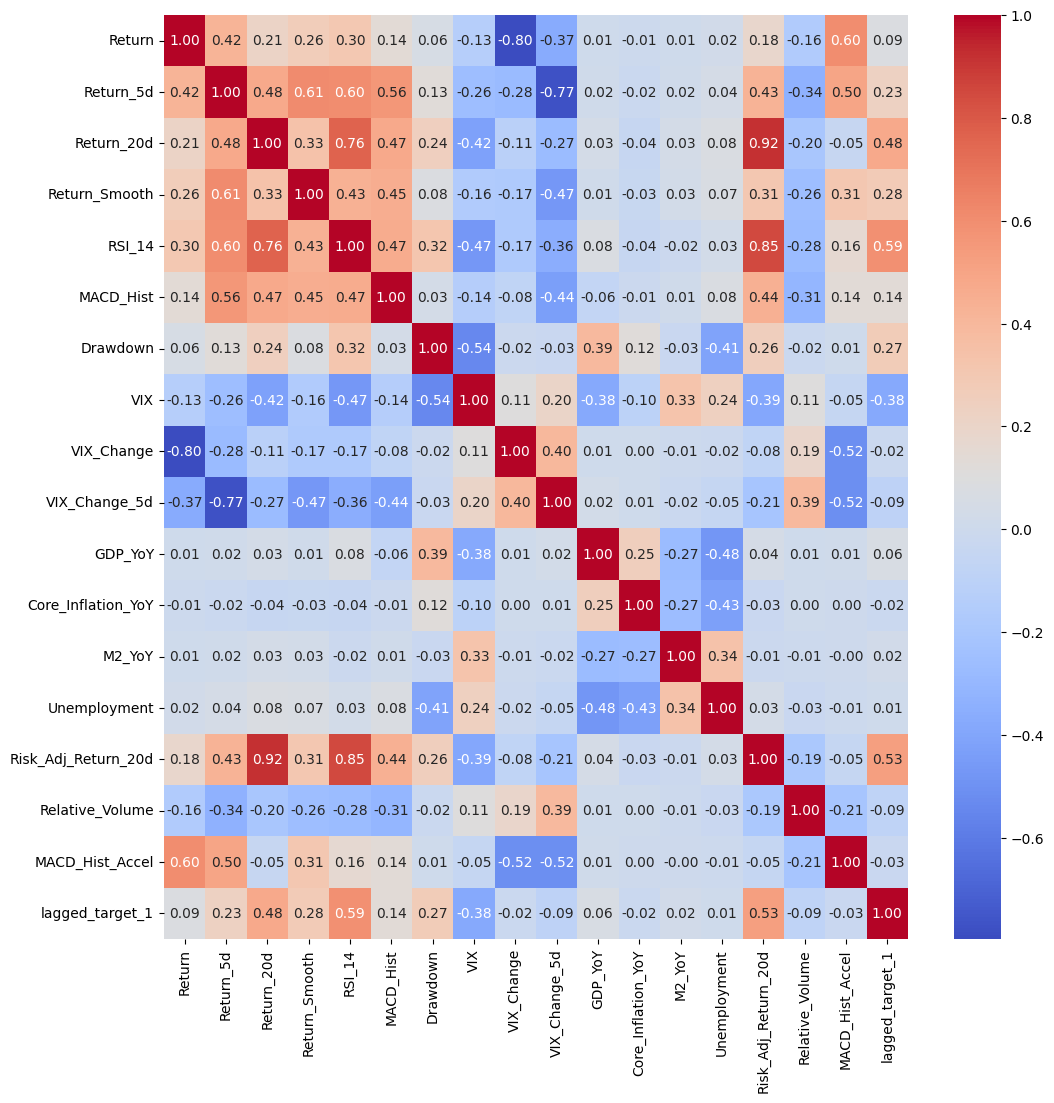

In [54]:
plt.figure(figsize=(12, 12))
cov_matrix = data_1[stationary_features + ['lagged_target_1']].corr()
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap='coolwarm')

In [55]:
total_rows = len(data_1)

train_end = int(total_rows * 0.70)
val_end = int(total_rows * 0.85) 


scaler = preprocessing.StandardScaler()

X_train = X.iloc[:train_end]
X_train = scaler.fit_transform(X_train)
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
X_val = scaler.transform(X_val)
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
X_test = scaler.transform(X_test)
y_test = y.iloc[val_end:]

In [56]:
print(f"Total trading days: {total_rows}")
print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Validation shapes: X={X_val.shape}, y={y_val.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

Total trading days: 8046
Training shapes: X=(5632, 17), y=(5632,)
Validation shapes: X=(1207, 17), y=(1207,)
Test shapes: X=(1207, 17), y=(1207,)


In [57]:

logit_model = sm.Logit(y_train, sm.add_constant(X_train))
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.405594
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:        lagged_target_1   No. Observations:                 5632
Model:                          Logit   Df Residuals:                     5614
Method:                           MLE   Df Model:                           17
Date:                Thu, 19 Mar 2026   Pseudo R-squ.:                  0.4027
Time:                        01:44:38   Log-Likelihood:                -2284.3
converged:                       True   LL-Null:                       -3824.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5136      0.041     12.409      0.000       0.432       0.595
x1            -0.1242      0.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, 'const'),
  Text(1, 0, 'Return'),
  Text(2, 0, 'Return_5d'),
  Text(3, 0, 'Return_20d'),
  Text(4, 0, 'Return_Smooth'),
  Text(5, 0, 'RSI_14'),
  Text(6, 0, 'MACD_Hist'),
  Text(7, 0, 'Drawdown'),
  Text(8, 0, 'VIX'),
  Text(9, 0, 'VIX_Change'),
  Text(10, 0, 'VIX_Change_5d'),
  Text(11, 0, 'GDP_YoY'),
  Text(12, 0, 'Core_Inflation_YoY'),
  Text(13, 0, 'M2_YoY'),
  Text(14, 0, 'Unemployment'),
  Text(15, 0, 'Risk_Adj_Return_20d'),
  Text(16, 0, 'Relative_Volume'),
  Text(17, 0, 'MACD_Hist_Accel')])

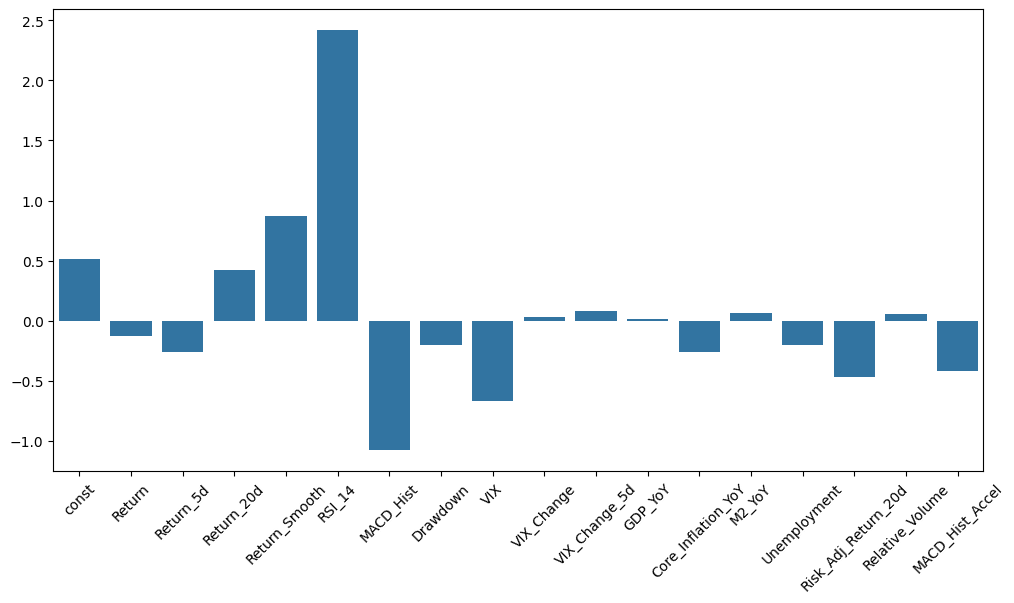

In [58]:
plt.figure(figsize=(12, 6))
names = ['const'] + list(X.columns)
sns.barplot(x=names, y=result.params.values)
plt.xticks(rotation=45)

In [59]:
threshold = 0.5
y_pred_prob_val = result.predict(sm.add_constant(X_val))
y_pred_val = (y_pred_prob_val >= threshold).astype(int)


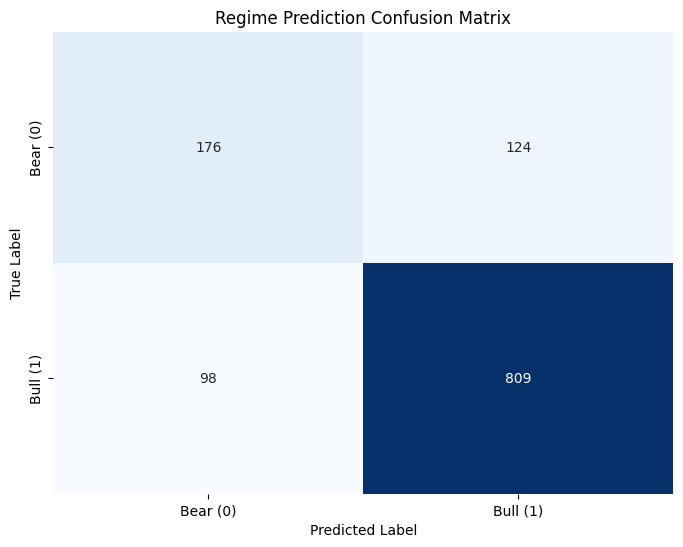

In [60]:

cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Bear (0)', 'Bull (1)'], 
            yticklabels=['Bear (0)', 'Bull (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Regime Prediction Confusion Matrix')
plt.show()

In [61]:

print(classification_report(y_val, y_pred_val, target_names=['Bear (0)', 'Bull (1)']))

              precision    recall  f1-score   support

    Bear (0)       0.64      0.59      0.61       300
    Bull (1)       0.87      0.89      0.88       907

    accuracy                           0.82      1207
   macro avg       0.75      0.74      0.75      1207
weighted avg       0.81      0.82      0.81      1207



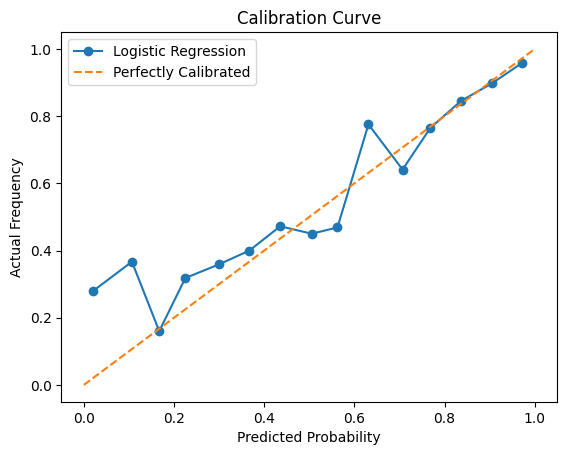

In [62]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_val, y_pred_prob_val, n_bins=15)

plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Frequency')
plt.title('Calibration Curve')
plt.legend()
plt.show()

In [63]:
from sklearn.metrics import fbeta_score
thresholds = np.linspace(0, 1, 50)
beta = 2 
f_scores = []
for t in thresholds:

    y_pred_temp = (y_pred_prob_val >= t).astype(int)
    f_scores.append(fbeta_score(y_val, y_pred_temp, beta=beta, pos_label=0))

best_threshold_f = thresholds[np.argmax(f_scores)]
print(f"Best Threshold (F-{beta} Score): {best_threshold_f:.4f}")

Best Threshold (F-2 Score): 0.7959


Text(0, 0.5, 'F_beta_score')

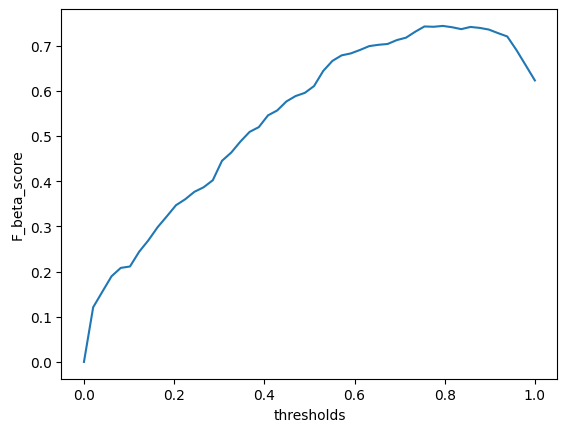

In [64]:
sns.lineplot(x=thresholds, y=f_scores)
plt.xlabel('thresholds')
plt.ylabel('F_beta_score')

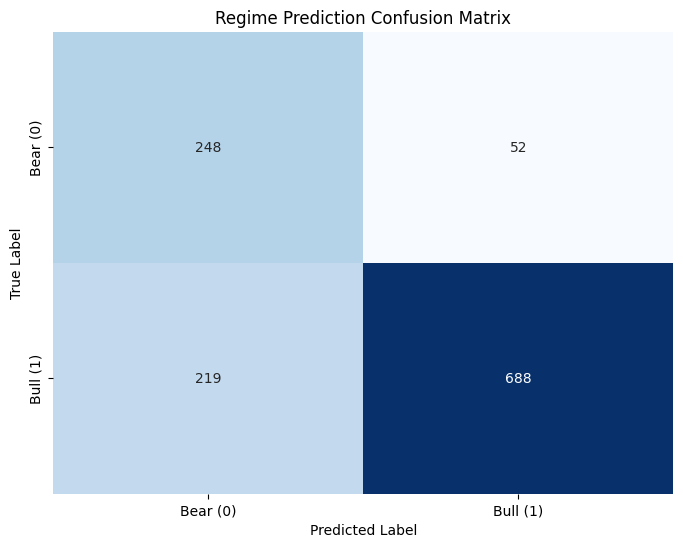

              precision    recall  f1-score   support

    Bear (0)       0.53      0.83      0.65       300
    Bull (1)       0.93      0.76      0.84       907

    accuracy                           0.78      1207
   macro avg       0.73      0.79      0.74      1207
weighted avg       0.83      0.78      0.79      1207



In [65]:
threshold = 0.7959
y_pred_prob_val = result.predict(sm.add_constant(X_val))
y_pred_val = (y_pred_prob_val >= threshold).astype(int)
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Bear (0)', 'Bull (1)'], 
            yticklabels=['Bear (0)', 'Bull (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Regime Prediction Confusion Matrix')
plt.show()
print(classification_report(y_val, y_pred_val, target_names=['Bear (0)', 'Bull (1)']))

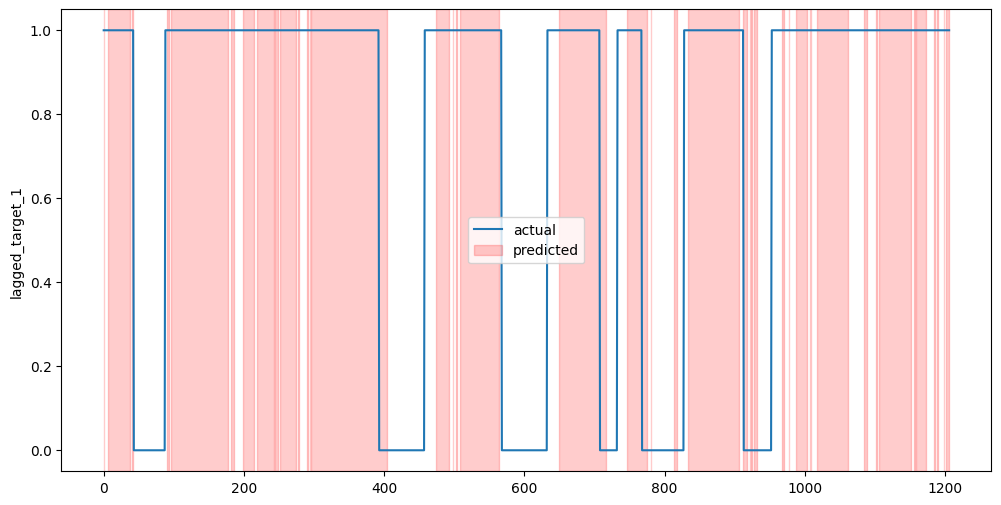

In [66]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=range(len(X_val)), y=y_val, label='actual')
plt.fill_between(
    range(len(X_val)),
    0, 1, 
    where=(y_pred_val == 1),              
    color='red',                              
    alpha=0.2,                                 
    transform=plt.gca().get_xaxis_transform(), 
    label='predicted'
)

plt.legend()

In [67]:
model =  XGBClassifier(n_estimators=150, random_state=0,max_depth=5, learning_rate=0.1)

model.fit(
    X_train, 
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=10  
)

[0]	validation_0-logloss:0.62417	validation_1-logloss:0.58731
[10]	validation_0-logloss:0.36074	validation_1-logloss:0.42660
[20]	validation_0-logloss:0.25160	validation_1-logloss:0.37619
[30]	validation_0-logloss:0.19478	validation_1-logloss:0.34562
[40]	validation_0-logloss:0.15420	validation_1-logloss:0.33035
[50]	validation_0-logloss:0.12317	validation_1-logloss:0.31222
[60]	validation_0-logloss:0.10065	validation_1-logloss:0.29732
[70]	validation_0-logloss:0.08534	validation_1-logloss:0.28798
[80]	validation_0-logloss:0.06890	validation_1-logloss:0.27963
[90]	validation_0-logloss:0.05925	validation_1-logloss:0.27685
[100]	validation_0-logloss:0.05142	validation_1-logloss:0.27683
[110]	validation_0-logloss:0.04372	validation_1-logloss:0.27404
[120]	validation_0-logloss:0.03821	validation_1-logloss:0.27182
[130]	validation_0-logloss:0.03396	validation_1-logloss:0.26771
[140]	validation_0-logloss:0.02999	validation_1-logloss:0.27073
[149]	validation_0-logloss:0.02702	validation_1-log

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [68]:
results = model.evals_result()

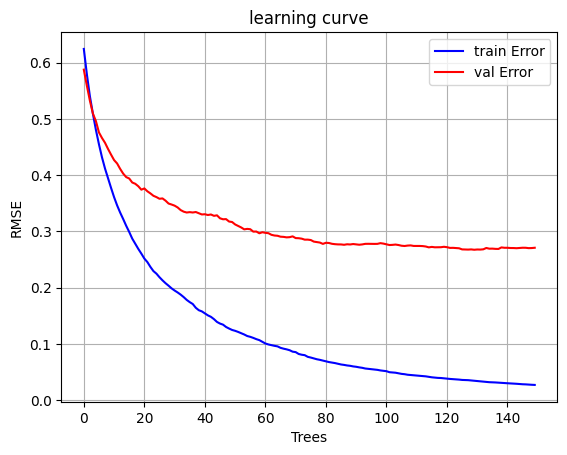

In [69]:
results = model.evals_result()
train_rmse = results['validation_0']['logloss']
val_rmse = results['validation_1']['logloss']

plt.plot(train_rmse, label='train Error', color='blue')
plt.plot(val_rmse, label='val Error', color='red')
plt.title('learning curve')
plt.xlabel('Trees')
plt.ylabel('RMSE')
plt.legend()
plt.grid()
plt.show()

<Axes: >

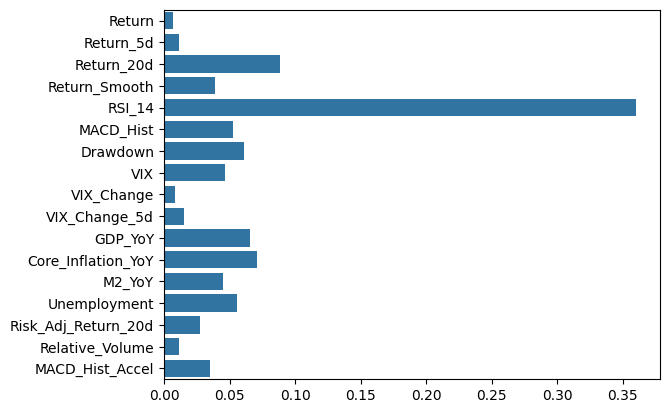

In [70]:
sns.barplot(x=model.feature_importances_, y=names[1:])

Best Threshold (Youden's J): 0.8920


<Axes: >

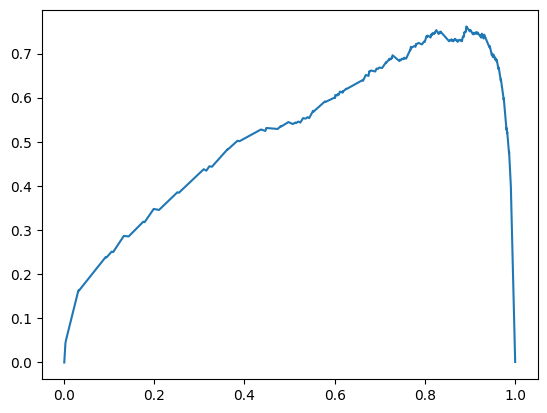

In [71]:
y_pred_prob_val = model.predict_proba(X_val)[:, 1].flatten()


fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob_val)
# J = TPR – FPR
j_scores = tpr - fpr
best_threshold = thresholds[np.argmax(j_scores)]
print(f"Best Threshold (Youden's J): {best_threshold:.4f}")
sns.lineplot(x=thresholds, y=j_scores)

In [72]:
# y_pred_val = model.predict(X_val)
best_threshold = 0.838
y_pred_val = (y_pred_prob_val >= best_threshold).astype(int)

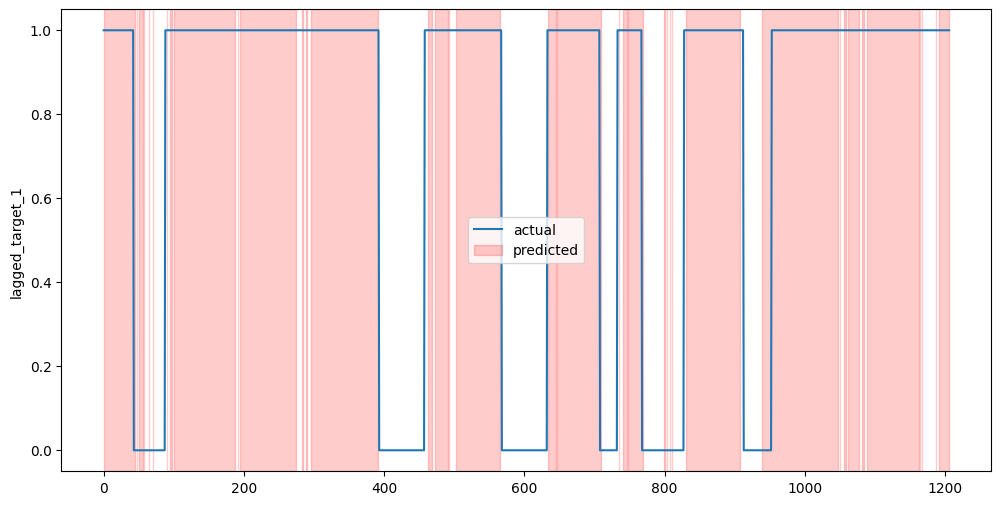

In [73]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=range(len(X_val)), y=y_val, label='actual')
plt.fill_between(
    range(len(X_val)),
    0, 1, 
    where=(y_pred_val == 1),              
    color='red',                              
    alpha=0.2,                                 
    transform=plt.gca().get_xaxis_transform(), 
    label='predicted'
)

plt.legend()

<Axes: xlabel='col_0', ylabel='lagged_target_1'>

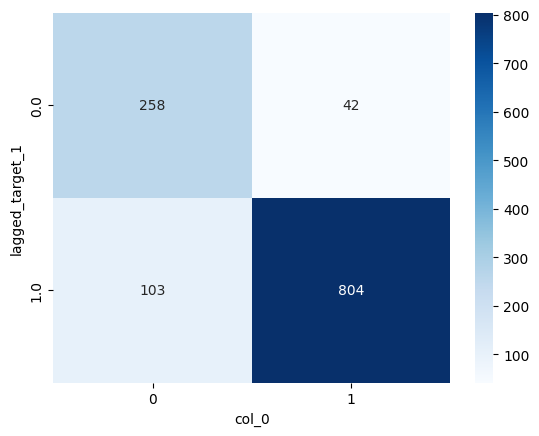

In [74]:
sns.heatmap(pd.crosstab(y_val, y_pred_val), annot=True, fmt='d', cmap='Blues')

<Axes: xlabel='col_0', ylabel='lagged_target_1'>

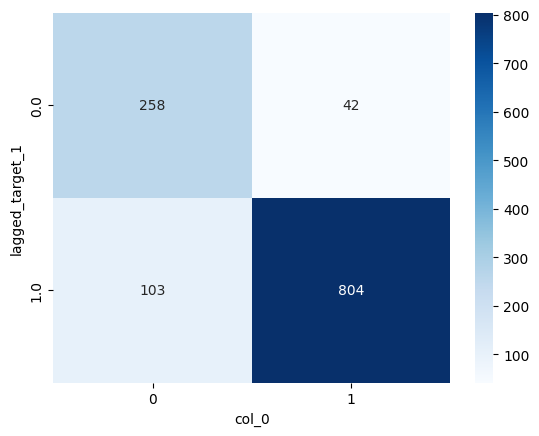

In [75]:
sns.heatmap(pd.crosstab(y_val, y_pred_val), annot=True, fmt='d', cmap='Blues')

In [76]:
import shap
explainer = shap.TreeExplainer(model)

shap_values = explainer(pd.DataFrame(X_val, columns=names[1:]))

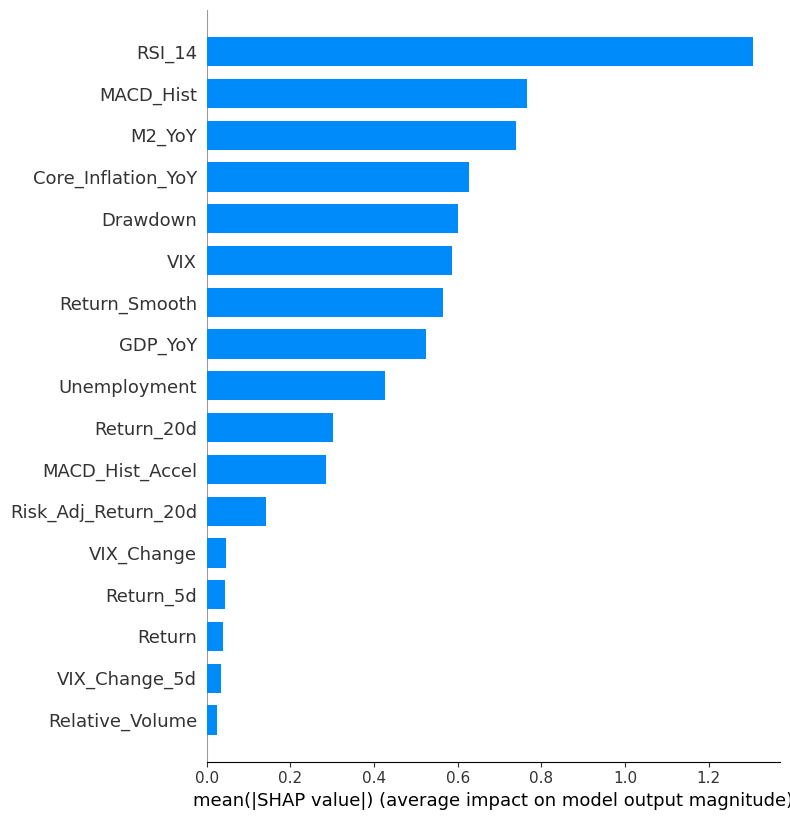

In [77]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, feature_names=names[1:], plot_type='bar')

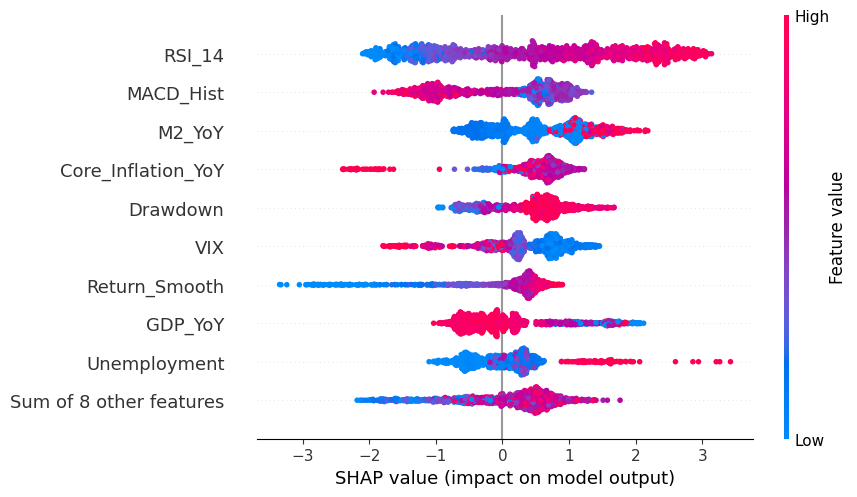

In [78]:
shap.plots.beeswarm(shap_values)


In [79]:
from pathlib import Path

LOGISTIC_OUTPUT_DIR = Path("../../../reports/trained_logistic/basecase_1day")
XGBOOST_OUTPUT_DIR = Path("../../../reports/trained_xgboost/basecase_1day")

LOGISTIC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
XGBOOST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

validation_dates = data_1["Date"].iloc[train_end:val_end].reset_index(drop=True)

logistic_pred_prob_val = result.predict(sm.add_constant(X_val))
logistic_pred_val = (logistic_pred_prob_val >= threshold).astype(int)
logistic_confusion = pd.DataFrame(
    confusion_matrix(y_val, logistic_pred_val),
    index=["actual_bear", "actual_bull"],
    columns=["pred_bear", "pred_bull"],
)
logistic_confusion.to_csv(LOGISTIC_OUTPUT_DIR / "confusion_matrix.csv")

logistic_metrics = pd.DataFrame([
    {
        "model": "logistic_regression",
        "split": "validation",
        "horizon": "1day",
        "accuracy": accuracy_score(y_val, logistic_pred_val),
        "precision": precision_score(y_val, logistic_pred_val, zero_division=0),
        "recall": recall_score(y_val, logistic_pred_val, zero_division=0),
        "f1_score": f1_score(y_val, logistic_pred_val, zero_division=0),
        "threshold": threshold,
    }
])
logistic_metrics.to_csv(LOGISTIC_OUTPUT_DIR / "validation_metrics.csv", index=False)

pd.DataFrame({"feature": names, "coefficient": result.params.values}).to_csv(LOGISTIC_OUTPUT_DIR / "coefficients.csv", index=False)

pd.DataFrame({
    "Date": validation_dates,
    "y_true": y_val.reset_index(drop=True),
    "y_pred": pd.Series(logistic_pred_val).reset_index(drop=True),
    "y_pred_prob": pd.Series(logistic_pred_prob_val).reset_index(drop=True),
    "model": "logistic_regression",
    "split": "validation",
    "horizon": "1day",
}).to_csv(LOGISTIC_OUTPUT_DIR / "predictions.csv", index=False)

plt.figure(figsize=(6, 5))
sns.heatmap(logistic_confusion, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix (1 Day)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(LOGISTIC_OUTPUT_DIR / "confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.close()

plt.figure(figsize=(12, 6))
sns.lineplot(x=range(len(X_val)), y=y_val.reset_index(drop=True), label='actual')
plt.fill_between(
    range(len(X_val)),
    0,
    1,
    where=(pd.Series(logistic_pred_val).reset_index(drop=True) == 1),
    color='red',
    alpha=0.2,
    transform=plt.gca().get_xaxis_transform(),
    label='predicted',
)
plt.title('Logistic Regression Prediction Timeline (1 Day)')
plt.xlabel('Validation Observation')
plt.ylabel('Regime')
plt.legend()
plt.tight_layout()
plt.savefig(LOGISTIC_OUTPUT_DIR / "prediction_timeline.png", dpi=180, bbox_inches="tight")
plt.close()

xgb_confusion = pd.DataFrame(
    confusion_matrix(y_val, y_pred_val),
    index=["actual_bear", "actual_bull"],
    columns=["pred_bear", "pred_bull"],
)
xgb_confusion.to_csv(XGBOOST_OUTPUT_DIR / "confusion_matrix.csv")

xgb_metrics = pd.DataFrame([
    {
        "model": "xgboost",
        "split": "validation",
        "horizon": "1day",
        "accuracy": accuracy_score(y_val, y_pred_val),
        "precision": precision_score(y_val, y_pred_val, zero_division=0),
        "recall": recall_score(y_val, y_pred_val, zero_division=0),
        "f1_score": f1_score(y_val, y_pred_val, zero_division=0),
        "threshold": best_threshold,
    }
])
xgb_metrics.to_csv(XGBOOST_OUTPUT_DIR / "validation_metrics.csv", index=False)

pd.DataFrame({
    "Date": validation_dates,
    "y_true": y_val.reset_index(drop=True),
    "y_pred": pd.Series(y_pred_val).reset_index(drop=True),
    "y_pred_prob": pd.Series(y_pred_prob_val).reset_index(drop=True),
    "model": "xgboost",
    "split": "validation",
    "horizon": "1day",
}).to_csv(XGBOOST_OUTPUT_DIR / "predictions.csv", index=False)

pd.DataFrame({"feature": names[1:], "importance": model.feature_importances_}).to_csv(XGBOOST_OUTPUT_DIR / "feature_importance.csv", index=False)

plt.figure(figsize=(6, 5))
sns.heatmap(xgb_confusion, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix (1 Day)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(XGBOOST_OUTPUT_DIR / "confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.close()

plt.figure(figsize=(12, 6))
sns.lineplot(x=range(len(X_val)), y=y_val.reset_index(drop=True), label='actual')
plt.fill_between(
    range(len(X_val)),
    0,
    1,
    where=(pd.Series(y_pred_val).reset_index(drop=True) == 1),
    color='red',
    alpha=0.2,
    transform=plt.gca().get_xaxis_transform(),
    label='predicted',
)
plt.title('XGBoost Prediction Timeline (1 Day)')
plt.xlabel('Validation Observation')
plt.ylabel('Regime')
plt.legend()
plt.tight_layout()
plt.savefig(XGBOOST_OUTPUT_DIR / "prediction_timeline.png", dpi=180, bbox_inches="tight")
plt.close()

learning_curve_df = pd.DataFrame({
    "iteration": range(len(results['validation_0']['logloss'])),
    "train_logloss": results['validation_0']['logloss'],
    "val_logloss": results['validation_1']['logloss'],
})
learning_curve_df.to_csv(XGBOOST_OUTPUT_DIR / "learning_curve.csv", index=False)

print(f"Saved logistic regression outputs to {LOGISTIC_OUTPUT_DIR}")
print(f"Saved XGBoost outputs to {XGBOOST_OUTPUT_DIR}")


Saved logistic regression outputs to ../../../reports/trained_logistic/basecase_1day
Saved XGBoost outputs to ../../../reports/trained_xgboost/basecase_1day
